# 03 · Efectividad y Modelo Predictivo

Cuantificación de efectividad por OBV y xG, análisis espacial 360 y modelo Random Forest sencillo para rankear patrones tácticos por valor observado.

Carga desde `data/processed/` — requiere haber corrido `01_preprocessing` al menos una vez.

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch, FontManager
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='husl')

_here = Path().resolve()
_root = _here.parent if _here.name == 'notebooks' else _here
RAW_DIR       = _root / 'data' / 'raw'
PROCESSED_DIR = _root / 'data' / 'processed'
Path(_root / 'figures').mkdir(exist_ok=True)
print('OK')

OK


## 1 · Efectividad - OBV y xG

### 1.1 · Tabla de efectividad y distribuciones OBV/xG

                n  obv_mean  obv_median  shot_rate  counter_rate  xg_mean  xg_p75
corner_type                                                                      
Inswinging   4594    0.0151     -0.0120       34.1           0.7   0.0346  0.0408
Outswinging  5590    0.0121     -0.0068       42.4           0.9   0.0343  0.0467
Short        2644   -0.0091     -0.0123       34.0           0.8   0.0277  0.0234
Straight      451    0.0115     -0.0039       41.9           0.7   0.0294  0.0343


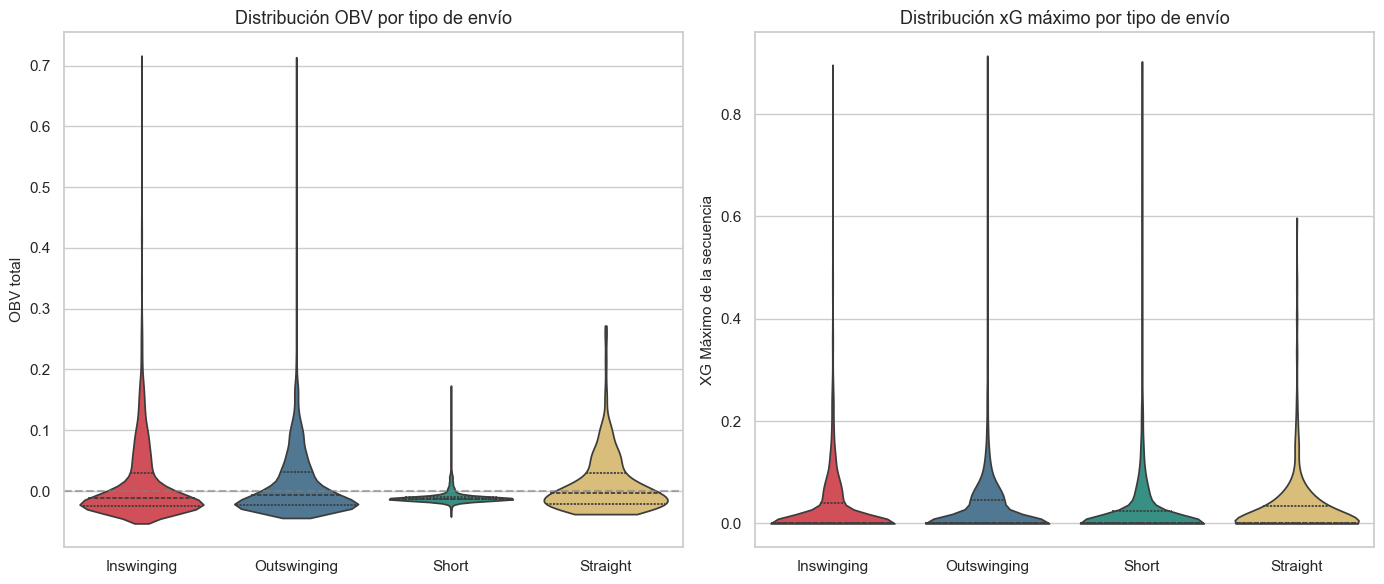

In [2]:
# Carga de datasets (cada notebook es autónomo)
corner_features = pd.read_parquet(PROCESSED_DIR / 'corner_features.parquet')
from_corner_enr = pd.read_parquet(PROCESSED_DIR / 'from_corner_enriched.parquet')
shots_fc        = pd.read_parquet(PROCESSED_DIR / 'shots_from_corner.parquet')
shots_sp        = pd.read_parquet(PROCESSED_DIR / 'shots_second_phase.parquet')

TYPES       = ['Inswinging', 'Outswinging', 'Short', 'Straight']
COLORS_TYPE = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a']
BG          = '#0d1b2a'

# Tabla de efectividad
effectiveness = (
    corner_features.groupby('corner_type', observed=True).agg(
        n            = ('id', 'count'),
        obv_mean     = ('obv_total_net', 'mean'),
        obv_median   = ('obv_total_net', 'median'),
        shot_rate    = ('generated_shot', 'mean'),
        counter_rate = ('led_to_counter', 'mean'),
        xg_mean      = ('seq_max_xg', lambda x: x.fillna(0).mean()),
        xg_p75       = ('seq_max_xg', lambda x: x.fillna(0).quantile(0.75)),
    ).reindex(TYPES)
)
for col in ['shot_rate', 'counter_rate']:
    effectiveness[col] = (effectiveness[col] * 100).round(1)
print(effectiveness.round(4).to_string())

# Violin plots OBV y xG
plot_data = corner_features[['corner_type', 'obv_total_net', 'seq_max_xg']].copy()
plot_data['seq_max_xg'] = plot_data['seq_max_xg'].fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.violinplot(data=plot_data, x='corner_type', y='obv_total_net',
               order=TYPES, hue='corner_type', palette=COLORS_TYPE,
               legend=False, ax=ax1, inner='quartile', cut=0)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.6)
ax1.set_title('Distribución OBV por tipo de envío', fontsize=13)
ax1.set_xlabel('')
ax1.set_ylabel('OBV total', fontsize=11)
sns.violinplot(data=plot_data, x='corner_type', y='seq_max_xg',
               order=TYPES, hue='corner_type', palette=COLORS_TYPE,
               legend=False, ax=ax2, inner='quartile', cut=0)
ax2.set_title('Distribución xG máximo por tipo de envío', fontsize=13)
ax2.set_xlabel('')
ax2.set_ylabel('XG Máximo de la secuencia', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/obv_xg_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 · xG por origen de remate y métricas avanzadas

In [3]:
# xG por origen de remate
print('xG por origen de remate:')
for label, df in [
    ('Directo',       shots_fc[shots_fc['shot_origin'] == 'direct']),
    ('Indirecto',     shots_fc[shots_fc['shot_origin'] == 'non_direct']),
    ('Segunda fase',  shots_sp),
]:
    xg = df['shot_statsbomb_xg'].dropna()
    print(f'  {label:<15}: n={len(xg):>4}  mean={xg.mean():.4f}  median={xg.median():.4f}  p75={xg.quantile(0.75):.4f}')

# execution_xg_uplift por equipo (mínimo 20 remates en córner para estabilidad)
print('\nTop 10 equipos por ejecución de remates desde córner (uplift > 0 = supera xG esperado):')
uplift = (
    corner_features[corner_features['best_shot_execution_xg_uplift'].notna()]
    .groupby('team')['best_shot_execution_xg_uplift'].agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_uplift', 'count': 'n_shots'})
    .query('n_shots >= 20')
    .sort_values('avg_uplift', ascending=False)
)
print(uplift.head(10).round(4).to_string())

# OBV defensivo de despejes por tipo de córner
# (negativo = la defensa recuperó más valor con ese tipo de envío)
clearances = from_corner_enr[from_corner_enr['type'] == 'Clearance']
def_obv = (
    clearances.groupby('corner_type', observed=True)['obv_total_net']
    .agg(n='count', mean='mean', median='median')
    .reindex(TYPES)
)
print('\nOBV de despejes por tipo de córner (negativo = defensa recuperó más valor):')
print(def_obv.round(4).to_string())

xG por origen de remate:
  Directo        : n=2605  mean=0.0725  median=0.0591  p75=0.0861
  Indirecto      : n=1474  mean=0.0898  median=0.0584  p75=0.1076
  Segunda fase   : n= 110  mean=0.0891  median=0.0365  p75=0.0812

Top 10 equipos por ejecución de remates desde córner (uplift > 0 = supera xG esperado):
                   avg_uplift  n_shots
team                                  
Juárez                 0.0215      231
Guadalajara            0.0090      260
Pumas UNAM             0.0044      294
Puebla                 0.0010      275
Atlético San Luis     -0.0010      256
Toluca                -0.0017      277
Mazatlán              -0.0031      241
Monterrey             -0.0056      297
Atlas                 -0.0059      269
Pachuca               -0.0071      312

OBV de despejes por tipo de córner (negativo = defensa recuperó más valor):
                n    mean  median
corner_type                      
Inswinging   2878  0.0054  0.0114
Outswinging  3645  0.0069  0.0124
Short  

### 1.3 · Riesgo vs recompensa

                n  shot_rate  counter_rate  retained_rate  xg_mean  obv_mean
corner_type                                                                 
Inswinging   4594       34.1           0.7           24.2   0.0346    0.0151
Outswinging  5590       42.4           0.9           20.7   0.0343    0.0121
Short        2644       34.0           0.8           26.0   0.0277   -0.0091
Straight      451       41.9           0.7           20.8   0.0294    0.0115

Mann-Whitney xG (two-sided) + effect size:
  Inswinging   vs Outswinging : p=0.0000  rbc=+0.062
  Inswinging   vs Short       : p=0.0420  rbc=-0.024
  Outswinging  vs Short       : p=0.0000  rbc=-0.097


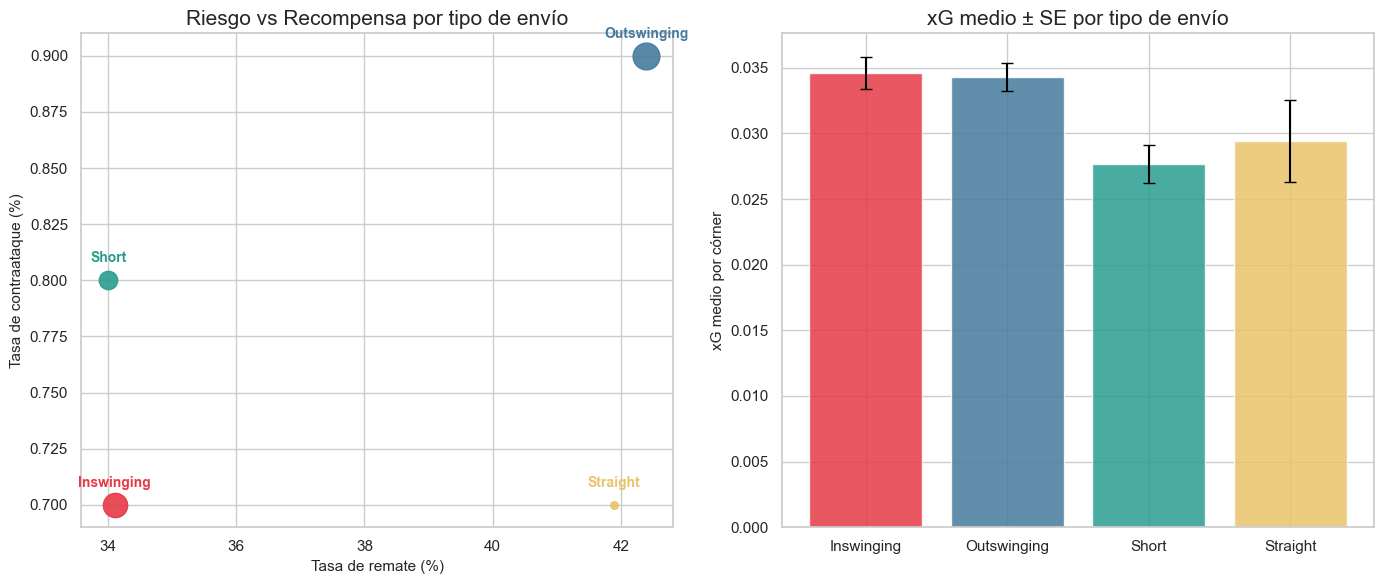

In [4]:
# Tabla riesgo-recompensa
rr = corner_features.groupby('corner_type', observed=True).agg(
    n             = ('id', 'count'),
    shot_rate     = ('generated_shot', 'mean'),
    counter_rate  = ('led_to_counter', 'mean'),
    retained_rate = ('sequence_outcome', lambda x: (x == 'retained').mean()),
    xg_mean       = ('seq_max_xg', lambda x: x.fillna(0).mean()),
    obv_mean      = ('obv_total_net', 'mean'),
).reindex(TYPES)
for col in ['shot_rate', 'counter_rate', 'retained_rate']:
    rr[col] = (rr[col] * 100).round(1)
print(rr.round(4).to_string())

# Mann-Whitney: xG no es normal (skewed, muchos ceros) → Mann-Whitney es mejor que t-test
# Effect size: rank-biserial correlation (rbc > 0.1 = pequeño, > 0.3 = medio)
pairs = [('Inswinging', 'Outswinging'), ('Inswinging', 'Short'), ('Outswinging', 'Short')]
print('\nMann-Whitney xG (two-sided) + effect size:')
for t1, t2 in pairs:
    a = corner_features[corner_features['corner_type'] == t1]['seq_max_xg'].fillna(0)
    b = corner_features[corner_features['corner_type'] == t2]['seq_max_xg'].fillna(0)
    stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rbc = 1 - 2 * stat / (len(a) * len(b))
    print(f'  {t1:<12} vs {t2:<12}: p={p:.4f}  rbc={rbc:+.3f}')

# Scatter riesgo vs recompensa + bar xG medio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for ctype, color in zip(TYPES, COLORS_TYPE):
    row = rr.loc[ctype]
    ax1.scatter(row['shot_rate'], row['counter_rate'],
                s=row['n'] / 15, color=color, alpha=0.9, zorder=5)
    ax1.annotate(ctype, (row['shot_rate'], row['counter_rate'] + 0.008),
                 ha='center', fontsize=10, fontweight='bold', color=color)
ax1.set_xlabel('Tasa de remate (%)', fontsize=11)
ax1.set_ylabel('Tasa de contraataque (%)', fontsize=11)
ax1.set_title('Riesgo vs Recompensa por tipo de envío', fontsize=15)

means = [corner_features[corner_features['corner_type'] == t]['seq_max_xg'].fillna(0).mean() for t in TYPES]
sems  = [corner_features[corner_features['corner_type'] == t]['seq_max_xg'].fillna(0).sem()  for t in TYPES]
ax2.bar(TYPES, means, color=COLORS_TYPE, edgecolor='white', alpha=0.85)
ax2.errorbar(TYPES, means, yerr=sems, fmt='none', color='black', capsize=4, lw=1.5)
ax2.set_ylabel('xG medio por córner', fontsize=11)
ax2.set_title('xG medio ± SE por tipo de envío', fontsize=15)

plt.tight_layout()
plt.savefig('../figures/risk_reward.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 · Primera acción post-envío

In [5]:
# Distribución de primera acción significativa tras el envío por tipo de córner
action_stats = (
    corner_features[corner_features['first_action_type'].notna()]
    .groupby(['corner_type', 'first_action_type'], observed=True)['id'].count()
    .unstack(fill_value=0)
)
action_pct = action_stats.div(action_stats.sum(axis=1), axis=0).mul(100).round(1)
print('Primera acción post-envío (% por tipo de córner):')
print(action_pct.reindex(TYPES).to_string())

# OBV medio por tipo de primera acción (filtrar acciones con ≥50 eventos)
obv_by_action = (
    corner_features.groupby('first_action_type', observed=True)['obv_total_net']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean', ascending=False)
)
print('\nOBV medio por primera acción (n ≥ 50):')
print(obv_by_action.round(4).to_string())

Primera acción post-envío (% por tipo de córner):
first_action_type  Bad Behaviour  Ball Recovery  Block  Carry  Clearance  Dispossessed  Dribble  Duel  Foul Committed  Goal Keeper  Half End  Half Start  Injury Stoppage  Interception  Miscontrol  Player Off  Player On  Shield  Shot  Substitution  Tactical Shift
corner_type                                                                                                                                                                                                                                                           
Inswinging                   0.0            6.8    4.7   42.3       13.2           0.0      0.0  17.2             3.1          2.9       0.0         0.8              0.1           0.1         0.8         0.1        0.0     0.1   7.4           0.4             0.1
Outswinging                  0.0            6.6    4.1   43.1       10.9           0.0      0.0  21.2             2.9          0.3       0.0         0.6         

## 2 · Análisis espacial 360

### 2.1 · Conteo de atacantes por zona táctica

In [6]:
ff_col = 'shot_freeze_frame'

# Merge corner_type a direct shots via shot_key_pass_id == corner_features.id
direct_shots = shots_fc[
    (shots_fc['shot_origin'] == 'direct') & shots_fc[ff_col].notna()
].merge(
    corner_features[['id', 'corner_type']].rename(columns={'id': 'shot_key_pass_id'}),
    on='shot_key_pass_id', how='left'
)

# Zonas tácticas (StatsBomb coords: pitch 120×80)
def in_6yd(x, y):  return (x >= 114) and (34 <= y <= 46)
def in_area(x, y): return (x >= 102) and (18 <= y <= 62)

def count_role_in_zone(ff, is_teammate, zone_fn):
    c = 0
    for p in ff:
        if p.get('teammate', False) != is_teammate:
            continue
        loc = p.get('location')
        if not hasattr(loc, '__len__') or len(loc) < 2:
            continue
        if zone_fn(float(loc[0]), float(loc[1])):
            c += 1
    return c

direct_shots['att_6yd']  = direct_shots[ff_col].apply(lambda ff: count_role_in_zone(list(ff), True,  in_6yd))
direct_shots['att_area'] = direct_shots[ff_col].apply(lambda ff: count_role_in_zone(list(ff), True,  in_area))
direct_shots['def_area'] = direct_shots[ff_col].apply(lambda ff: count_role_in_zone(list(ff), False, in_area))

spatial = (
    direct_shots.groupby('corner_type', observed=True)
    [['att_6yd', 'att_area', 'def_area', 'shot_statsbomb_xg']]
    .mean().reindex(TYPES)
)
print('Promedio de jugadores por zona táctica y xG (remates directos de córner):')
print(spatial.round(3).to_string())

print('\nCorrelación jugadores en zona vs xG del remate:')
print(direct_shots[['att_6yd', 'att_area', 'def_area', 'shot_statsbomb_xg']].corr()['shot_statsbomb_xg'].round(3).to_string())

Promedio de jugadores por zona táctica y xG (remates directos de córner):
             att_6yd  att_area  def_area  shot_statsbomb_xg
corner_type                                                
Inswinging     1.025     4.539     9.502              0.094
Outswinging    0.480     4.566     9.438              0.065
Short          0.190     5.063     8.975              0.028
Straight       0.649     4.603     9.168              0.051

Correlación jugadores en zona vs xG del remate:
att_6yd              0.193
att_area            -0.076
def_area            -0.005
shot_statsbomb_xg    1.000


### 2.2 · Heatmap de posiciones de atacantes (freeze frame 360)

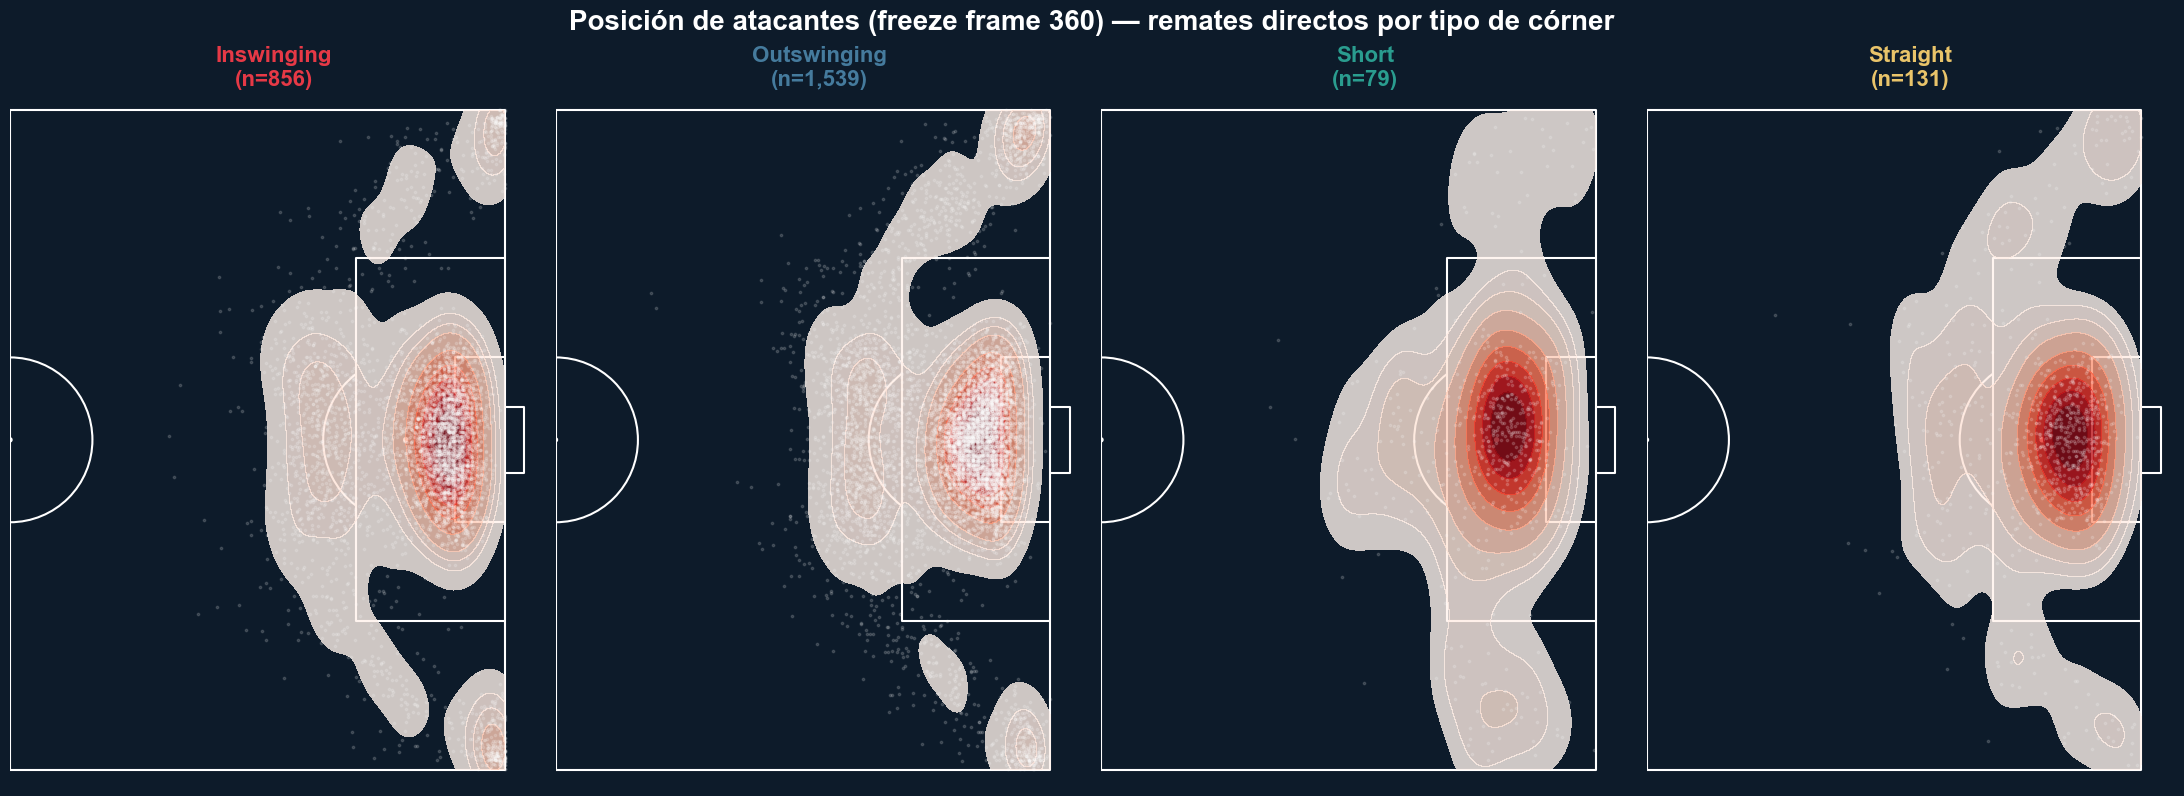

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(22, 8))
for ax, ctype, color in zip(axes, TYPES, COLORS_TYPE):
    pitch = Pitch(pitch_type='statsbomb', pitch_color=BG, line_color='#ffffff66',
                  linewidth=1.5, goal_type='box')
    pitch.draw(ax=ax)
    subset = direct_shots[direct_shots['corner_type'] == ctype]
    att_xs, att_ys = [], []
    for _, row in subset.iterrows():
        for player in list(row[ff_col]):
            if not player.get('teammate', False):
                continue
            loc = player.get('location')
            if not hasattr(loc, '__len__') or len(loc) < 2:
                continue
            att_xs.append(float(loc[0]))
            att_ys.append(float(loc[1]))
    if len(att_xs) > 20:
        pitch.kdeplot(att_xs, att_ys, ax=ax, cmap='Reds', fill=True, alpha=0.8, levels=10, thresh=0.05)
        pitch.scatter(att_xs, att_ys, ax=ax, s=3, alpha=0.15, color='white', zorder=3)
    ax.set_xlim(60, 124)
    ax.set_ylim(-2, 82)
    ax.set_title(f'{ctype}\n(n={len(subset):,})', color=color, fontsize=16, fontweight='bold')
    ax.set_facecolor(BG)

fig.patch.set_facecolor(BG)
fig.suptitle('Posición de atacantes (freeze frame 360) — remates directos por tipo de córner',
             color='white', fontsize=20, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/attacker_positions_freeze.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 3 · Modelo ML sencillo: valor táctico del envío

El reto no pide sólo predecir remates: pide convertir córners en recomendaciones simples para un cuerpo técnico. Aquí modelamos el **valor del envío** con `obv_total_net`: una métrica disponible para el evento del pase que captura impacto ofensivo/defensivo incluso cuando no hay remate. Después traducimos las predicciones a métricas futbolísticas: xG por córner, tasa de remate, retención y contraataque.


### 3.1 · Dataset, target y política de variables


In [8]:
from scipy.stats import spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

FIGURES_DIR = _root / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# Cada fila sigue siendo un corner. Quitamos solo filas sin OBV del envio porque OBV es el target.
# No quitamos corners sin remate: esos siguen siendo informativos y tienen xG=0.
model_df = corner_features.dropna(subset=['obv_total_net']).copy()
model_df['match_date'] = pd.to_datetime(model_df['match_date'])
model_df = model_df.sort_values(['match_date', 'match_id', 'id']).reset_index(drop=True)

# Target principal: valor neto del envio. Metric as target, not as feature.
model_df['target_obv'] = model_df['obv_total_net']

# Metricas auxiliares para traducir el modelo a futbol: peligro, volumen y riesgo.
model_df['xg_per_corner'] = model_df['seq_sum_xg'].fillna(0)
model_df['target_shot'] = model_df['generated_shot'].astype(int)

# Zonas simples y entendibles para un staff. Evitan que la recomendacion dependa
# solo de coordenadas crudas como end_x/end_y.
x, y = model_df['end_x'], model_df['end_y']
model_df['end_zone'] = np.select(
    [
        (x >= 114) & y.between(34, 46),
        (x >= 108) & y.between(24, 56),
        (x >= 102) & y.between(18, 62),
        x >= 96,
    ],
    ['six_yard', 'central_box', 'wide_box', 'edge_or_short'],
    default='recycled',
)
model_df['distance_to_goal_center'] = np.hypot(120 - x, 40 - y)
model_df['dominant_foot'] = (
    ((model_df['corner_side'] == 'left') & (model_df['pass_body_part'] == 'Right Foot')) |
    ((model_df['corner_side'] == 'right') & (model_df['pass_body_part'] == 'Left Foot'))
).astype(int)
model_df['is_playoff'] = (~model_df['competition_stage'].isin(['Apertura', 'Clausura', 'Regular Season'])).astype(int)
model_df['has_360'] = model_df['num_defenders_on_goal_side_of_actor'].notna().astype(int)

# Politica de variables: no se trata de excluir mucho, sino de no mezclar causas con consecuencias.
variable_policy = pd.DataFrame({
    'grupo': ['features', 'sensibilidad', 'targets / metricas', 'outcomes excluidos'],
    'uso': [
        'Diseno y ejecucion del envio: tipo, lado, pie, zona, longitud, angulo, minuto y 360.',
        'pass_success_probability: modelo externo StatsBomb; se prueba, no lidera la recomendacion.',
        'OBV como target; xG, remate, retencion y contraataque para traducir resultados.',
        'seq_*, n_*, first_action_type, best_shot_*: ya conocen el resultado de la secuencia.',
    ],
})

display(variable_policy)

# Este resumen verifica que el test 2024/2025 no es identico al train.
split_summary = model_df.groupby('season').agg(
    n=('id', 'count'),
    obv_mean=('target_obv', 'mean'),
    xg_per_100=('xg_per_corner', lambda s: 100 * s.mean()),
    shot_rate=('target_shot', 'mean'),
    counter_per_100=('led_to_counter', lambda s: 100 * s.mean()),
).round(4)
display(split_summary)


,grupo,uso
0,features,"Diseno y ejecucion del envio: tipo, lado, pie,..."
1,sensibilidad,pass_success_probability: modelo externo Stats...
2,targets / metricas,"OBV como target; xG, remate, retencion y contr..."
3,outcomes excluidos,"seq_*, n_*, first_action_type, best_shot_*: ya..."


,n,obv_mean,xg_per_100,shot_rate,counter_per_100
season,,,,,
2021/2022,3046,0.0075,3.5124,0.3828,0.8536
2022/2023,3286,0.0105,3.8766,0.3932,0.7608
2023/2024,3342,0.0090,3.5747,0.3965,1.0174
2024/2025,3346,0.0083,3.5911,0.3715,0.7173


### 3.2 · Entrenamiento simple y validación temporal


In [9]:
# Features disponibles para describir el diseno/ejecucion del corner.
# No entran resultados de la secuencia: n_shots, seq_xg, first_action, best_shot, etc.
cat_features = ['corner_type', 'corner_side', 'pass_height', 'pass_body_part', 'end_zone']
num_features = [
    'pass_length', 'pass_angle', 'end_x', 'end_y', 'distance_to_goal_center',
    'minute', 'period', 'match_week', 'is_playoff', 'dominant_foot', 'has_360',
    'num_defenders_on_goal_side_of_actor', 'distance_to_nearest_defender',
    'visible_opponents', 'visible_teammates',
]

# Validacion temporal: entrenar con temporadas pasadas y evaluar en la futura.
# Esto es mas honesto que mezclar partidos de 2024/2025 dentro de folds aleatorios.
train = model_df['season'] != '2024/2025'
test = model_df['season'] == '2024/2025'
X_train, y_train = model_df.loc[train, cat_features + num_features], model_df.loc[train, 'target_obv']
X_test, y_test = model_df.loc[test, cat_features + num_features], model_df.loc[test, 'target_obv']

# Pipeline pequeno: imputacion + one-hot + RF poco profundo.
# La profundidad baja fuerza interpretabilidad y reduce overfit en patrones raros.
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=25, sparse_output=False), cat_features),
])
rf_obv = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=250, max_depth=4, min_samples_leaf=60,
        random_state=42, n_jobs=1,
    )),
])

# Baseline: si el modelo no supera predecir la media historica, no hay senal util.
dummy = DummyRegressor(strategy='mean')
dummy.fit(np.zeros((len(y_train), 1)), y_train)
rf_obv.fit(X_train, y_train)

pred_dummy = dummy.predict(np.zeros((len(y_test), 1)))
pred_obv = rf_obv.predict(X_test)

def regression_metrics(name, y_true, pred):
    # MAE/RMSE miden precision numerica. Spearman mide ranking: si los corners
    # que el modelo ve como mejores realmente terminan arriba en OBV.
    pred_range = np.nanmax(pred) - np.nanmin(pred)
    spearman = np.nan if pred_range < 1e-12 else spearmanr(y_true, pred).statistic
    return {
        'model': name,
        'mae': mean_absolute_error(y_true, pred),
        'rmse': mean_squared_error(y_true, pred) ** 0.5,
        'r2': r2_score(y_true, pred),
        'spearman': spearman,
    }

metrics_obv = pd.DataFrame([
    regression_metrics('baseline_mean', y_test, pred_dummy),
    regression_metrics('rf_obv', y_test, pred_obv),
])
display(metrics_obv.round(4))

# Sensibilidad: pass_success_probability no es outcome puro, pero si es un modelo externo.
# Si mejora poco, no conviene basar la historia en esa columna.
num_features_success = num_features + ['pass_success_probability']
preprocessor_success = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_features_success),
    ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=25, sparse_output=False), cat_features),
])
rf_success = Pipeline([
    ('prep', preprocessor_success),
    ('model', RandomForestRegressor(
        n_estimators=250, max_depth=4, min_samples_leaf=60,
        random_state=42, n_jobs=1,
    )),
])
rf_success.fit(model_df.loc[train, cat_features + num_features_success], y_train)
pred_success = rf_success.predict(model_df.loc[test, cat_features + num_features_success])

sensitivity = pd.DataFrame([
    regression_metrics('rf_obv_base', y_test, pred_obv),
    regression_metrics('rf_plus_pass_success_probability', y_test, pred_success),
])
display(sensitivity.round(4))


,model,mae,rmse,r2,spearman
0,baseline_mean,0.0355,0.0553,-0.0002,NaN
1,rf_obv,0.0313,0.0535,0.0662,0.194


,model,mae,rmse,r2,spearman
0,rf_obv_base,0.0313,0.0535,0.0662,0.194
1,rf_plus_pass_success_probability,0.0307,0.0532,0.0775,0.242


### 3.3 · Diagnóstico: el modelo rankea mejor que predice


,n,pred_obv,actual_obv,xg_per_100,shot_rate,counter_per_100
0,447,-0.0155,-0.0159,2.2234,0.2595,0.6711
1,266,-0.0125,-0.0125,2.8383,0.2820,0.3759
2,291,-0.0045,0.0003,2.8649,0.2990,0.3436
3,335,0.0056,0.0084,3.1533,0.2716,0.5970
4,334,0.0111,0.0044,3.0700,0.3084,0.8982
5,335,0.0151,0.0141,3.8252,0.3881,0.2985
6,334,0.0163,0.0160,4.2000,0.5749,0.8982
7,335,0.0173,0.0215,4.0386,0.4896,1.1940
8,334,0.0188,0.0213,4.4375,0.4581,1.4970
9,335,0.0241,0.0283,5.4696,0.3940,0.2985


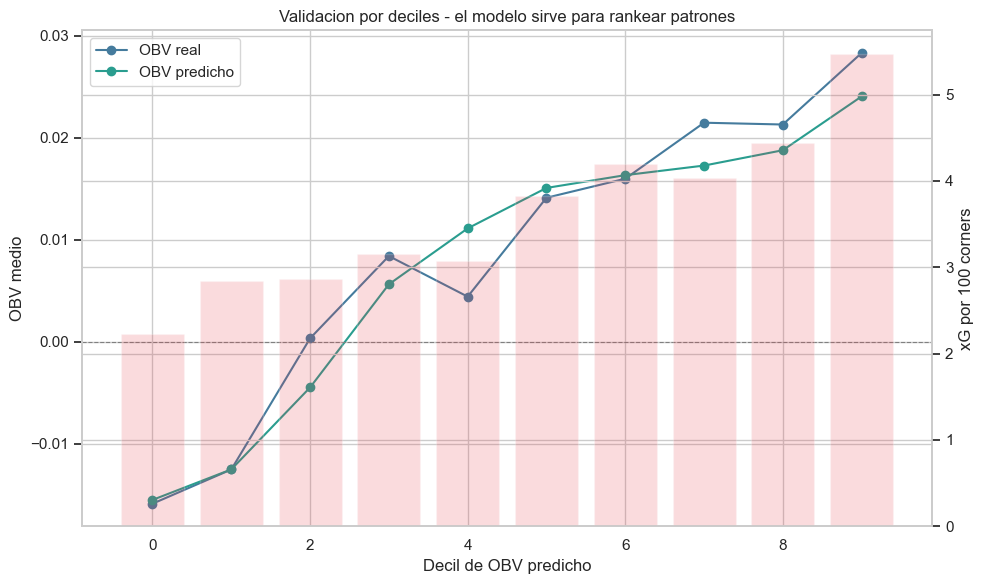

,feature,mae_increase
9,distance_to_goal_center,0.00491
7,end_x,0.00142
5,pass_length,0.00027
0,corner_type,0.00004
6,pass_angle,0.00003
2,pass_height,0.00003
17,distance_to_nearest_defender,0.00001
10,minute,0.00001
8,end_y,0.00001
19,visible_teammates,0.00000


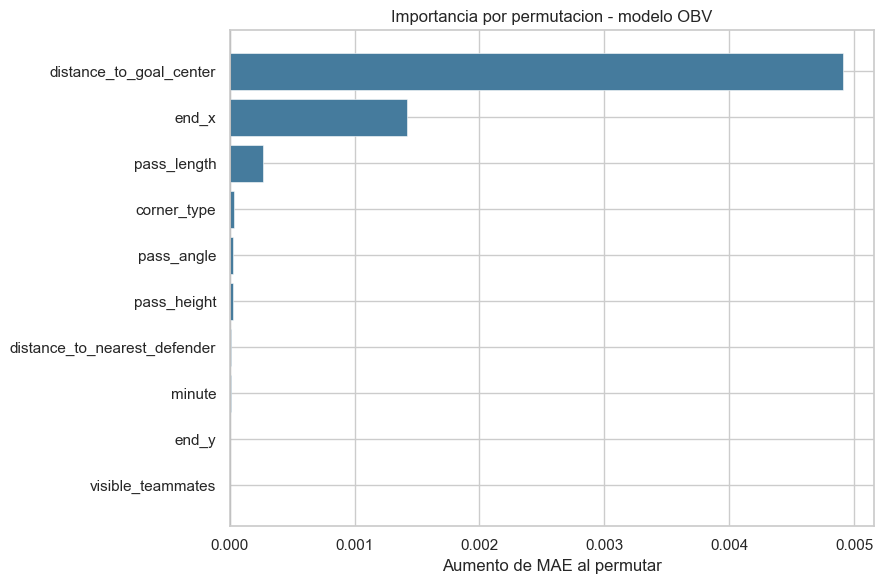

In [10]:
# "Rankea mejor que predice" significa esto:
# - No esperamos que pred_obv sea exacto para un corner individual.
# - Si ordenamos los corners por pred_obv, los grupos de arriba deben tener mejor OBV/xG real.
# Por eso evaluamos deciles de prediccion, no solo R2.
test_pred = model_df.loc[test, [
    'id', 'corner_type', 'corner_side', 'end_zone', 'target_obv',
    'xg_per_corner', 'target_shot', 'led_to_counter', 'sequence_outcome',
]].copy()
test_pred['pred_obv'] = pred_obv
test_pred['pred_bin'] = pd.qcut(test_pred['pred_obv'], q=10, duplicates='drop')

obv_deciles = test_pred.groupby('pred_bin', observed=True).agg(
    n=('id', 'count'),
    pred_obv=('pred_obv', 'mean'),
    actual_obv=('target_obv', 'mean'),
    xg_per_100=('xg_per_corner', lambda s: 100 * s.mean()),
    shot_rate=('target_shot', 'mean'),
    counter_per_100=('led_to_counter', lambda s: 100 * s.mean()),
).reset_index(drop=True)

display(obv_deciles.round(4))

fig, ax1 = plt.subplots(figsize=(10, 6))
idx = np.arange(len(obv_deciles))
ax1.plot(idx, obv_deciles['actual_obv'], marker='o', color='#457b9d', label='OBV real')
ax1.plot(idx, obv_deciles['pred_obv'], marker='o', color='#2a9d8f', label='OBV predicho')
ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.set_xlabel('Decil de OBV predicho')
ax1.set_ylabel('OBV medio')
ax1.set_title('Validacion por deciles - el modelo sirve para rankear patrones')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.bar(idx, obv_deciles['xg_per_100'], alpha=0.18, color='#e63946', label='xG / 100')
ax2.set_ylabel('xG por 100 corners')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_obv_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

# Permutation importance: cuanto empeora el MAE si rompemos una columna.
# Si una variable importa, permutarla destruye informacion que el modelo usaba.
perm = permutation_importance(
    rf_obv, X_test, y_test, scoring='neg_mean_absolute_error',
    n_repeats=8, random_state=42, n_jobs=1,
)
importance = (
    pd.DataFrame({'feature': cat_features + num_features, 'mae_increase': perm.importances_mean})
    .sort_values('mae_increase', ascending=False)
)
display(importance.head(12).round(5))

fig, ax = plt.subplots(figsize=(9, 6))
plot_imp = importance.head(10).sort_values('mae_increase')
ax.barh(plot_imp['feature'], plot_imp['mae_increase'], color='#457b9d', edgecolor='white', lw=0.4)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Aumento de MAE al permutar')
ax.set_title('Importancia por permutacion - modelo OBV')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 · Recomendación desde el modelo


,corner_type,corner_side,end_zone,n,pred_obv_mean,actual_obv_mean,xg_per_100,shot_rate,counter_per_100,retained_rate,pattern
3,Outswinging,left,central_box,333,0.0160,0.0132,4.2194,0.4474,0.3003,0.1892,Outswinging / left / central_box
2,Inswinging,right,central_box,301,0.0160,0.0129,3.5410,0.3987,0.6645,0.2525,Inswinging / right / central_box
4,Outswinging,right,central_box,602,0.0155,0.0145,4.3225,0.4551,1.1628,0.2159,Outswinging / right / central_box
0,Inswinging,left,central_box,446,0.0154,0.0199,3.6384,0.4036,1.3453,0.2825,Inswinging / left / central_box
1,Inswinging,left,six_yard,233,0.0115,0.0203,4.3995,0.3176,0.8584,0.2747,Inswinging / left / six_yard
6,Short,right,edge_or_short,352,-0.0119,-0.0119,1.8573,0.2756,0.0000,0.2812,Short / right / edge_or_short
5,Short,left,edge_or_short,351,-0.0122,-0.0121,3.5158,0.3305,1.1396,0.2393,Short / left / edge_or_short


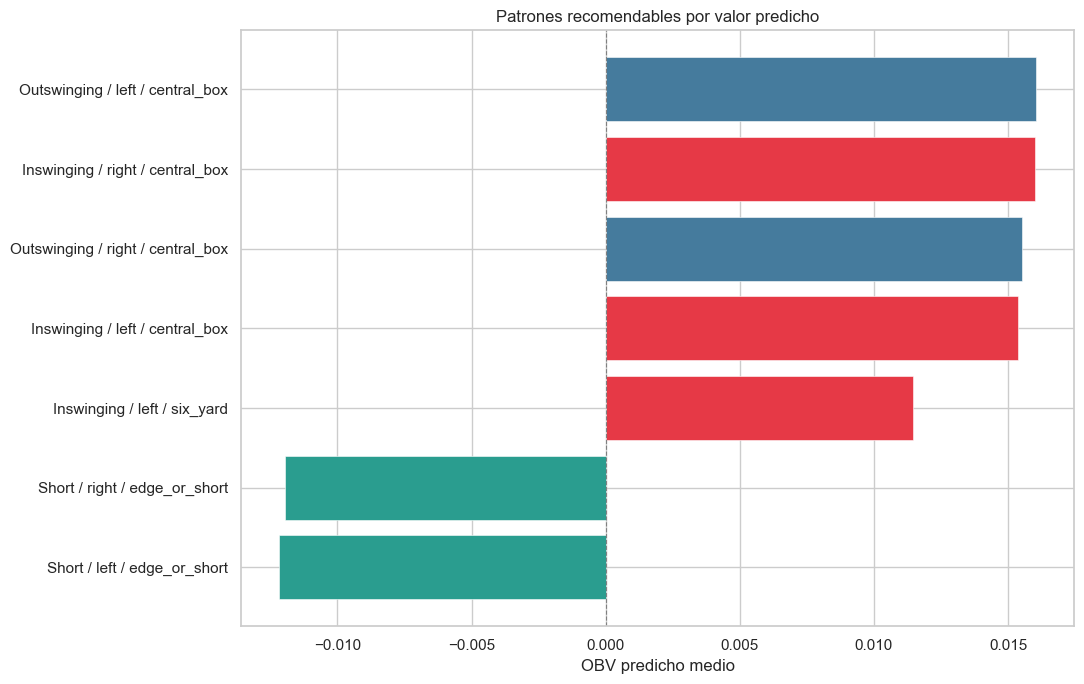

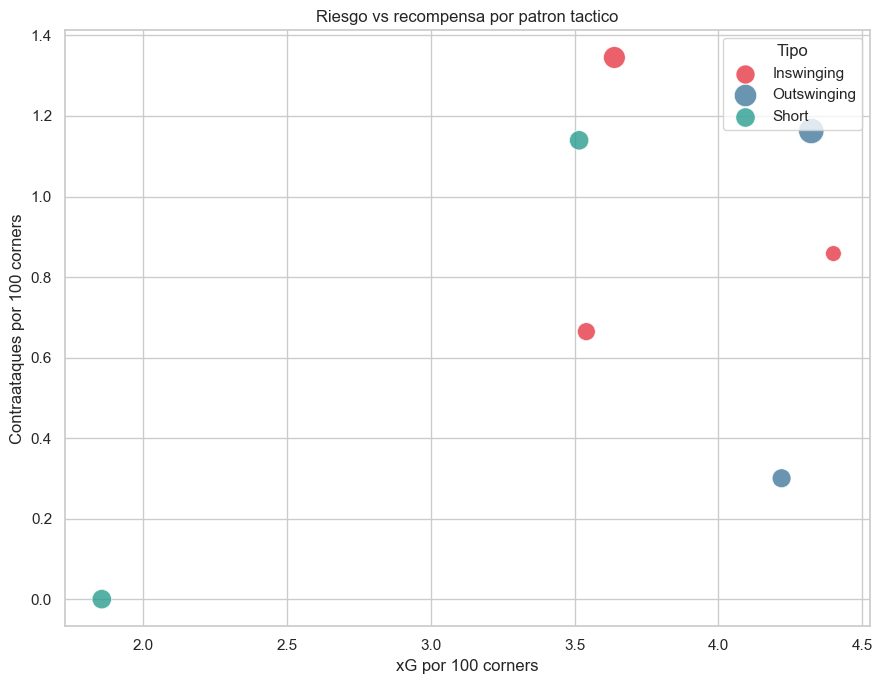

In [11]:
# Convertimos predicciones individuales en una tabla de decisiones tacticas.
# El filtro n>=150 evita recomendar patrones que aparecen muy poco.
pattern_stats = (
    test_pred
    .assign(retained=test_pred['sequence_outcome'].eq('retained'))
    .groupby(['corner_type', 'corner_side', 'end_zone'], observed=True)
    .agg(
        n=('id', 'count'),
        pred_obv_mean=('pred_obv', 'mean'),
        actual_obv_mean=('target_obv', 'mean'),
        xg_per_100=('xg_per_corner', lambda s: 100 * s.mean()),
        shot_rate=('target_shot', 'mean'),
        counter_per_100=('led_to_counter', lambda s: 100 * s.mean()),
        retained_rate=('retained', 'mean'),
    )
    .query('n >= 150')
    .reset_index()
)
pattern_stats['pattern'] = (
    pattern_stats['corner_type'] + ' / ' + pattern_stats['corner_side'] + ' / ' + pattern_stats['end_zone']
)
pattern_stats = pattern_stats.sort_values(['pred_obv_mean', 'xg_per_100'], ascending=False)
display(pattern_stats.head(12).round(4))

# Grafica 1: que patrones prioriza el modelo por OBV predicho.
color_by_type = dict(zip(TYPES, COLORS_TYPE))
fig, ax = plt.subplots(figsize=(11, 7))
plot_patterns = pattern_stats.head(10).sort_values('pred_obv_mean')
ax.barh(
    plot_patterns['pattern'], plot_patterns['pred_obv_mean'],
    color=plot_patterns['corner_type'].map(color_by_type), edgecolor='white', lw=0.4,
)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('OBV predicho medio')
ax.set_title('Patrones recomendables por valor predicho')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_pattern_recommendation.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafica 2: traduccion futbolistica. Buen patron = mas xG sin disparar contraataques.
fig, ax = plt.subplots(figsize=(9, 7))
for ctype in TYPES:
    sub = pattern_stats[pattern_stats['corner_type'] == ctype]
    if sub.empty:
        continue
    ax.scatter(
        sub['xg_per_100'], sub['counter_per_100'],
        s=sub['n'] * 0.55, color=color_by_type[ctype], alpha=0.8,
        edgecolor='white', linewidth=0.5, label=ctype,
    )
ax.set_xlabel('xG por 100 corners')
ax.set_ylabel('Contraataques por 100 corners')
ax.set_title('Riesgo vs recompensa por patron tactico')
ax.legend(title='Tipo')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'model_risk_reward.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Conclusiones y Hallazgos

---

### 4.1 · Efectividad general: no todo remate vale igual

Outswinging es el envío de mayor volumen y tasa de remate: **42.4%** de sus córners terminan en disparo, contra **34.1%** de Inswinging y **34.0%** de Short. Pero el xG medio por córner es casi igual entre Outswinging (**0.0343**) e Inswinging (**0.0346**). La conclusión es importante: **más remates no necesariamente significa más peligro agregado**.

Short corners tienen el perfil más débil como estrategia base: OBV medio **-0.0091**, xG medio **0.0277** y tasa de remate **34.0%**. Sí retienen más posesión (**26.0%**), pero esa retención no compensa por sí sola la caída en valor ofensivo. Su uso tiene más sentido como variante situacional para cambiar ritmo o desordenar una defensa, no como reemplazo masivo de envíos al área.

---

### 4.2 · Riesgo defensivo: el contraataque no domina la decisión

El riesgo de contraataque es bajo para todos los tipos: Inswinging **0.7%**, Outswinging **0.9%**, Short **0.8%** y Straight **0.7%**. Por eso el análisis no debe sobrerreaccionar al miedo de la contra. La decisión principal debe venir del balance entre valor ofensivo, zona de envío y plan del rival.

La retención sí cambia por tipo: Short retiene más (**26.0%**) que Inswinging (**24.2%**) y Outswinging (**20.7%**). Esto refuerza que los córners cortos pueden ser útiles cuando el objetivo es conservar y reorganizar, pero no cuando el objetivo principal es maximizar peligro inmediato.

---

### 4.3 · Segunda fase y primera acción: entrenar el rebote importa

Los remates indirectos y de segunda fase tienen más xG medio que los remates directos:

| Origen | n | xG medio |
|---|---:|---:|
| Directo | 2,605 | 0.0725 |
| Indirecto | 1,474 | 0.0898 |
| Segunda fase | 110 | 0.0891 |

Esto sugiere que una parte relevante del valor no nace sólo del primer contacto, sino de la segunda jugada: rechaces, recuperaciones y pases posteriores. La primera acción significativa también apunta en esa dirección: cuando la primera acción es `Shot`, el OBV medio es **0.0815**; cuando es `Duel`, **0.0374**; cuando es `Clearance`, **-0.0089**. Entrenar ocupación para el rebote y presión tras despeje es tan importante como elegir Inswinging u Outswinging.

---

### 4.4 · Hallazgo espacial 360: la zona pesa más que la etiqueta

El freeze frame 360 muestra que Inswinging genera remates directos de mayor calidad: xG medio **0.094** en remates directos, contra **0.065** de Outswinging y **0.028** de Short. También mete más atacantes en área chica: **1.03** atacantes en 6-yard box vs **0.48** en Outswinging. La correlación entre atacantes en área chica y xG del remate es **0.193**, suficiente para sostener una lectura táctica: no basta con mandar el balón al área; importa cuántos atacantes atacan zonas de alto valor.

Esto conecta con el modelo: la importancia por permutación indica que `distance_to_goal_center` y `end_x` pesan más que `corner_type`. En lenguaje de staff: **la zona del envío explica más que el nombre del envío**.

---

### 4.5 · Modelo ML: útil para rankear, no para predecir exacto

El modelo de OBV mejora al baseline, pero no es fuerte como predictor individual. En test temporal `2024/2025`, el baseline de media obtiene MAE **0.0355** y RMSE **0.0553**; el Random Forest mejora a MAE **0.0313**, RMSE **0.0535**, R² **0.066** y Spearman **0.194**.

"Rankea mejor que predice" significa que el número exacto de OBV para un córner aislado no es muy confiable, pero el orden de grupos sí aporta. Al dividir las predicciones en deciles, el decil más bajo tiene OBV real **-0.0159**, xG **2.22** por 100 córners y shot rate **25.9%**; el decil más alto llega a OBV real **0.0283**, xG **5.47** por 100 y shot rate **39.4%**. Es decir: el modelo sí separa patrones pobres de patrones prometedores.

La sensibilidad con `pass_success_probability` mejora poco: R² pasa de **0.066** a **0.078** y Spearman de **0.194** a **0.242**. Como es una estimación externa de StatsBomb, se reporta como sensibilidad, no como explicación principal.

---

### 4.6 · Recomendación accionable

La recomendación final no es elegir un único tipo de córner. Es construir un portafolio:

- Priorizar envíos a `central_box`, donde aparecen arriba tanto Inswinging como Outswinging.
- Mantener Outswinging para volumen: los patrones `Outswinging / left / central_box` y `Outswinging / right / central_box` rondan **4.2-4.3 xG por 100 córners** y **44-46%** de tasa de remate.
- Usar Inswinging para buscar calidad interior: `Inswinging / left / six_yard` alcanza **4.40 xG por 100** con buen OBV real, aunque con menor tasa de remate.
- Usar Short como variante, no como base: los patrones Short `edge_or_short` tienen OBV predicho y real negativos.
- Entrenar segunda fase: los remates indirectos y de segunda jugada tienen xG medio mayor que los directos.

---

### 4.7 · Limitaciones

El notebook no ve variables decisivas para un staff: marcador, lanzador específico bajo contexto, estructura defensiva rival, marca zonal vs individual, carreras de atacantes y scouting del rival. Por eso el modelo debe usarse como apoyo para priorizar patrones y preguntas de video, no como un sistema que predice con precisión cada córner.
